### Notebook 16

# **Cross-Validation Regression Models**

This cross-validation (CV) Notebook should be run at least twice, with *cv_iteration = 2* and *cv_iteration = 3*. The results for *cv_iteration = 1* can be obtained from Notebook 4. 

In [40]:
# Define cross-validation iteration. 
cv_iteration = 3

# Define the train set and test set for this iteration. 
if cv_iteration == 1:
    train_set = 'eegfmriNF'
    test_set = 'fmriNF'
elif cv_iteration == 2:
    train_set = 'eegNF'
    test_set = 'eegfmriNF'
elif cv_iteration == 3:
    train_set = 'fmriNF'
    test_set = 'eegNF'

## **1. Linear Regression, Ridge, Lasso**

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import pickle
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import xgboost as xgb
import os

In [42]:
# Define the preprocessed data path. 
preprocessed_data_path = '../neuropolis-x1_preprocessed_data/'

# Define the results path. 
results_path = '../neuropolis-x1_results/'

In [43]:
# Load the features, the targets, and the baseline. 
with open(preprocessed_data_path + 'dict_features_bandpowers_normalized.p', 'rb') as file:
    dict_features_bandpowers = pickle.load(file)
with open(preprocessed_data_path + 'dict_targets.p', 'rb') as file:
    dict_targets = pickle.load(file)
with open(preprocessed_data_path + 'dict_baseline.p', 'rb') as file:
    dict_baseline_original = pickle.load(file)

In [44]:
# Define the list of subjects, removing sub-xp102 who has a missing condition. 
subjects = ['sub-xp1' + str(x).zfill(2) for x in range(1, 11)]
subjects.remove('sub-xp102')
subject = subjects[0]

# Retrieve the list of all targets. 
targets = list(dict_targets[subject]['eegfmriNF'].keys())

# Select a sequence length. 
selected_sequence_length = 5

# Retrieve the total number of scans. 
nb_scans_total = dict_targets[subject]['eegfmriNF']['Frontal Pole'].shape[0]

In [45]:
# Define the dictionaries and the summary DataFrame for storing the features, targets, and baseline. 
dict_features_basis = dict()
dict_features_sequence = dict()
dict_targets_basis = dict()
dict_targets_sequence = dict()
dict_baseline_basis = dict()
dict_baseline_sequence = dict()
df_summary_global = pd.DataFrame()

# Iterate through all subjects. 
for subject in subjects:
        
    # Define the subject dictionaries. 
    dict_features_basis[subject] = dict()
    dict_features_sequence[subject] = dict()
    dict_targets_basis[subject] = dict()
    dict_targets_sequence[subject] = dict()
    dict_baseline_basis[subject] = dict()
    dict_baseline_sequence[subject] = dict()

    # Iterate through all conditions. 
    for condition in ['eegNF', 'fmriNF', 'eegfmriNF']:

        # Skip the current iteration for sub-xp102 and eegNF, since that run is missing. 
        if subject == 'sub-xp102' and condition == 'eegNF':
            continue
            
        # Define the general features array by stacking all the EEG channels. 
        X_basis = np.vstack(dict_features_bandpowers[subject][condition]).transpose()

        # Define the general targets array. 
        Y_basis = np.zeros((nb_scans_total, len(targets)))
        for target_index in range(len(targets)):
            Y_basis[:, target_index] = dict_targets[subject][condition][targets[target_index]]

        # Define the general baseline array. 
        Baseline_basis = np.zeros((nb_scans_total, len(targets)))
        for target_index in range(len(targets)):
            Baseline_basis[:, target_index] = dict_baseline_original[subject][condition][targets[target_index]]

        # Define the particular features array. 
        X_sequence = np.zeros((nb_scans_total - selected_sequence_length, X_basis.shape[1] * (selected_sequence_length + 1)))
        for scan in range(nb_scans_total - selected_sequence_length):
            X_sequence[scan, :] = X_basis[scan:(scan + selected_sequence_length + 1), :].ravel()

        # Define the particular targets array. 
        Y_sequence = Y_basis[selected_sequence_length:, :]

        # Define the particular baseline array. 
        Baseline_sequence = Baseline_basis[selected_sequence_length:, :]

        # Store the features, targets and baseline in the dictionaries. 
        dict_features_basis[subject][condition] = X_basis
        dict_features_sequence[subject][condition] = X_sequence
        dict_targets_basis[subject][condition] = Y_basis
        dict_targets_sequence[subject][condition] = Y_sequence
        dict_baseline_basis[subject][condition] = Baseline_basis
        dict_baseline_sequence[subject][condition] = Baseline_sequence

        # Store the shapes of the arrays in the DataFrame. 
        df_summary_global.loc[subject + '/' + condition, 'subject'] = subject
        df_summary_global.loc[subject + '/' + condition, 'condition'] = condition
        df_summary_global.loc[subject + '/' + condition, 'X_basis.shape'] = str(X_basis.shape)
        df_summary_global.loc[subject + '/' + condition, 'X_sequence.shape'] = str(X_sequence.shape)
        df_summary_global.loc[subject + '/' + condition, 'Y_basis.shape'] = str(Y_basis.shape)
        df_summary_global.loc[subject + '/' + condition, 'Y_sequence.shape'] = str(Y_sequence.shape)
        df_summary_global.loc[subject + '/' + condition, 'Baseline_basis.shape'] = str(Baseline_basis.shape)
        df_summary_global.loc[subject + '/' + condition, 'Baseline_sequence.shape'] = str(Baseline_sequence.shape)

# Change the indexes of the DataFrame. 
df_summary_global = df_summary_global.set_index(['subject', 'condition'])

In [46]:
# Display the summary DataFrame. 
df_summary_global

X_basis.shape X_sequence.shape Y_basis.shape  \
subject   condition                                                
sub-xp101 eegNF        (200, 378)      (195, 2268)     (200, 49)   
          fmriNF       (200, 378)      (195, 2268)     (200, 49)   
          eegfmriNF    (200, 378)      (195, 2268)     (200, 49)   
sub-xp103 eegNF        (200, 378)      (195, 2268)     (200, 49)   
          fmriNF       (200, 378)      (195, 2268)     (200, 49)   
          eegfmriNF    (200, 378)      (195, 2268)     (200, 49)   
sub-xp104 eegNF        (200, 378)      (195, 2268)     (200, 49)   
          fmriNF       (200, 378)      (195, 2268)     (200, 49)   
          eegfmriNF    (200, 378)      (195, 2268)     (200, 49)   
sub-xp105 eegNF        (200, 378)      (195, 2268)     (200, 49)   
          fmriNF       (200, 378)      (195, 2268)     (200, 49)   
          eegfmriNF    (200, 378)      (195, 2268)     (200, 49)   
sub-xp106 eegNF        (200, 378)      (195, 2268)     (200, 49)   
          fmriNF       (200, 378)      (195, 2268)     (200, 49)   
          eegfmriNF    (200, 378)      (195, 2268)     (200, 49)   
sub-xp107 eegNF        (200, 378)      (195, 2268)     (200, 49)   
          fmriNF       (200, 378)      (195, 2268)     (200, 49)   
          eegfmriNF    (200, 378)      (195, 2268)     (200, 49)   
sub-xp108 eegNF        (200, 378)      (195, 2268)     (200, 49)   
          fmriNF       (200, 378)      (195, 2268)     (200, 49)   
          eegfmriNF    (200, 378)      (195, 2268)     (200, 49)   
sub-xp109 eegNF        (200, 378)      (195, 2268)     (200, 49)   
          fmriNF       (200, 378)      (195, 2268)     (200, 49)   
          eegfmriNF    (200, 378)      (195, 2268)     (200, 49)   
sub-xp110 eegNF        (200, 378)      (195, 2268)     (200, 49)   
          fmriNF       (200, 378)      (195, 2268)     (200, 49)   
          eegfmriNF    (200, 378)      (195, 2268)     (200, 49)   

                    Y_sequence.shape Baseline_basis.shape  \
subject   condition                                         
sub-xp101 eegNF            (195, 49)            (200, 49)   
          fmriNF           (195, 49)            (200, 49)   
          eegfmriNF        (195, 49)            (200, 49)   
sub-xp103 eegNF            (195, 49)            (200, 49)   
          fmriNF           (195, 49)            (200, 49)   
          eegfmriNF        (195, 49)            (200, 49)   
sub-xp104 eegNF            (195, 49)            (200, 49)   
          fmriNF           (195, 49)            (200, 49)   
          eegfmriNF        (195, 49)            (200, 49)   
sub-xp105 eegNF            (195, 49)            (200, 49)   
          fmriNF           (195, 49)            (200, 49)   
          eegfmriNF        (195, 49)            (200, 49)   
sub-xp106 eegNF            (195, 49)            (200, 49)   
          fmriNF           (195, 49)            (200, 49)   
          eegfmriNF        (195, 49)            (200, 49)   
sub-xp107 eegNF            (195, 49)            (200, 49)   
          fmriNF           (195, 49)            (200, 49)   
          eegfmriNF        (195, 49)            (200, 49)   
sub-xp108 eegNF            (195, 49)            (200, 49)   
          fmriNF           (195, 49)            (200, 49)   
          eegfmriNF        (195, 49)            (200, 49)   
sub-xp109 eegNF            (195, 49)            (200, 49)   
          fmriNF           (195, 49)            (200, 49)   
          eegfmriNF        (195, 49)            (200, 49)   
sub-xp110 eegNF            (195, 49)            (200, 49)   
          fmriNF           (195, 49)            (200, 49)   
          eegfmriNF        (195, 49)            (200, 49)   

                    Baseline_sequence.shape  
subject   condition                          
sub-xp101 eegNF                   (195, 49)  
          fmriNF                  (195, 49)  
          eegfmriNF               (195, 49)  
sub-xp103 eegNF                   (195, 49)  
 

In [47]:
# Define the Mean Squared Error function. 
def MSE(y, y_pred):
    return np.mean(np.square(y - y_pred))

In [48]:
# Define the Mean Absolute Error function. 
def MAE(y, y_pred):
    return np.mean(np.abs(y - y_pred))

In [49]:
# Define the Residual Sum of Squares function. 
def RSS(y, y_pred):
    return np.sum(np.square(y - y_pred))

In [50]:
# Define a function to run a regression model. 
def run_regression_model(RegressionModel, dict_features_sequence, dict_targets_sequence, dict_baseline_sequence, parameter_name):

    # Define the dictionaries and the summary DataFrame. 
    dict_models = dict()
    dict_predictions = dict()
    df_summary = pd.DataFrame()

    # TRAINING LOOP. Iterate through all subjects. 
    for subject in subjects:

        # Display current subject. 
        print(subject)

        # Clone the Scikit-Learn estimator. 
        PredictorBrain = clone(RegressionModel)

        # Retrieve the features and targets of the train set. 
        X_tr = dict_features_sequence[subject][train_set]
        Y_tr = dict_targets_sequence[subject][train_set]

        # Train the model. 
        PredictorBrain.fit(X_tr, Y_tr)

        # Store the trained model in the dictionary. 
        dict_models[subject] = PredictorBrain

    # PREDICTION LOOP. Iterate through all subjects. 
    for subject in subjects:

        # Define the subject dictionary. 
        dict_predictions[subject] = dict()

        # Iterate through all conditions. 
        for condition in [test_set]:

            # Skip the current iteration for sub-xp102 and eegNF, since that run is missing. 
            if subject == 'sub-xp102' and condition == 'eegNF':
                continue

            # Retrieve the features and targets of the test set, the baseline, and the trained model. 
            X_te = dict_features_sequence[subject][condition]
            Y_te = dict_targets_sequence[subject][condition]
            Baseline = dict_baseline_sequence[subject][train_set]
            PredictorBrain = dict_models[subject]

            # Predict the target values. 
            Y_pred = PredictorBrain.predict(X_te)

            # Evaluate the performance metrics. 
            mse_baseline = MSE(Y_te, Baseline)
            mae_baseline = MAE(Y_te, Baseline)
            rss_baseline = RSS(Y_te, Baseline)
            mse_model = MSE(Y_te, Y_pred)
            mae_model = MAE(Y_te, Y_pred)
            rss_model = RSS(Y_te, Y_pred)
            r2_model = 1 - (rss_model / rss_baseline)

            # Store the performance metrics and the shapes of the arrays in the DataFrame. 
            df_summary.loc[subject + '/' + condition, 'subject'] = subject
            df_summary.loc[subject + '/' + condition, 'condition'] = condition
            df_summary.loc[subject + '/' + condition, 'mse_baseline'] = mse_baseline
            df_summary.loc[subject + '/' + condition, 'mae_baseline'] = mae_baseline
            df_summary.loc[subject + '/' + condition, 'rss_baseline'] = rss_baseline
            df_summary.loc[subject + '/' + condition, 'mse_model'] = mse_model
            df_summary.loc[subject + '/' + condition, 'mae_model'] = mae_model
            df_summary.loc[subject + '/' + condition, 'rss_model'] = rss_model
            df_summary.loc[subject + '/' + condition, 'r2_model'] = r2_model
            df_summary.loc[subject + '/' + condition, 'X_tr.shape'] = str(X_tr.shape)
            df_summary.loc[subject + '/' + condition, 'X_te.shape'] = str(X_te.shape)
            df_summary.loc[subject + '/' + condition, 'Y_tr.shape'] = str(Y_tr.shape)
            df_summary.loc[subject + '/' + condition, 'Y_te.shape'] = str(Y_te.shape)
            if parameter_name != '':
                df_summary.loc[subject + '/' + condition, parameter_name] = PredictorBrain.best_params_[parameter_name]

            # Store the predictions in the dictionary. 
            dict_predictions[subject][condition] = Y_pred

    # Change the indexes of the DataFrame. 
    df_summary = df_summary.set_index(['subject', 'condition'])
    
    return dict_models, dict_predictions, df_summary

In [51]:
# Run the regression model. 
dict_models_lr, dict_predictions_lr, df_summary_lr = run_regression_model(LinearRegression(), 
                                                                          dict_features_sequence, 
                                                                          dict_targets_sequence, 
                                                                          dict_baseline_sequence, 
                                                                          parameter_name = '')

sub-xp101
sub-xp103
sub-xp104
sub-xp105
sub-xp106
sub-xp107
sub-xp108
sub-xp109
sub-xp110


In [52]:
# Display the results. 
print('Linear Regression')
df_summary_lr

Linear Regression


,,mse_baseline,mae_baseline,rss_baseline,mse_model,mae_model,rss_model,r2_model,X_tr.shape,X_te.shape,Y_tr.shape,Y_te.shape
subject,condition,,,,,,,,,,,
sub-xp101,eegNF,0.748643,0.673287,7153.281594,1.176724,0.863430,11243.602340,-0.571810,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp103,eegNF,0.891261,0.764916,8515.998123,1.318364,0.913078,12596.969539,-0.479212,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp104,eegNF,0.754419,0.664922,7208.473926,1.251926,0.869493,11962.151253,-0.659457,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp105,eegNF,0.975536,0.788727,9321.244612,1.498088,0.985221,14314.228701,-0.535656,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp106,eegNF,0.960283,0.794260,9175.499629,1.149602,0.846900,10984.446125,-0.197150,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp107,eegNF,0.948845,0.783694,9066.210165,1.510346,0.985134,14431.359118,-0.591774,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp108,eegNF,0.971835,0.808577,9285.881629,1.397793,0.939184,13355.914982,-0.438303,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp109,eegNF,0.967838,0.813239,9247.691064,1.411464,0.963766,13486.534738,-0.458368,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp110,eegNF,0.958675,0.788212,9160.139889,1.441389,0.964512,13772.472438,-0.503522,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"


In [53]:
# Run the regression model. 
dict_models_ridge, dict_predictions_ridge, df_summary_ridge = run_regression_model(Ridge(), 
                                                                                   dict_features_sequence, 
                                                                                   dict_targets_sequence, 
                                                                                   dict_baseline_sequence, 
                                                                                   parameter_name = '')

sub-xp101
sub-xp103
sub-xp104
sub-xp105
sub-xp106
sub-xp107
sub-xp108
sub-xp109
sub-xp110


In [54]:
# Display the results. 
print('Ridge Regression')
df_summary_ridge

Ridge Regression


,,mse_baseline,mae_baseline,rss_baseline,mse_model,mae_model,rss_model,r2_model,X_tr.shape,X_te.shape,Y_tr.shape,Y_te.shape
subject,condition,,,,,,,,,,,
sub-xp101,eegNF,0.748643,0.673287,7153.281594,1.175579,0.862971,11232.661801,-0.570281,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp103,eegNF,0.891261,0.764916,8515.998123,1.317194,0.912672,12585.784144,-0.477899,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp104,eegNF,0.754419,0.664922,7208.473926,1.249608,0.868609,11940.002032,-0.656384,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp105,eegNF,0.975536,0.788727,9321.244612,1.496901,0.984837,14302.893212,-0.534440,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp106,eegNF,0.960283,0.794260,9175.499629,1.148089,0.846364,10969.992909,-0.195574,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp107,eegNF,0.948845,0.783694,9066.210165,1.506647,0.983954,14396.010854,-0.587875,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp108,eegNF,0.971835,0.808577,9285.881629,1.395494,0.938436,13333.941229,-0.435937,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp109,eegNF,0.967838,0.813239,9247.691064,1.410102,0.963312,13473.527894,-0.456961,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp110,eegNF,0.958675,0.788212,9160.139889,1.439545,0.963910,13754.848354,-0.501598,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"


In [55]:
# Run the regression model. 
dict_models_lasso, dict_predictions_lasso, df_summary_lasso = run_regression_model(Lasso(), 
                                                                                   dict_features_sequence, 
                                                                                   dict_targets_sequence, 
                                                                                   dict_baseline_sequence, 
                                                                                   parameter_name = '')

sub-xp101
sub-xp103
sub-xp104
sub-xp105
sub-xp106
sub-xp107
sub-xp108
sub-xp109
sub-xp110


In [56]:
# Display the results. 
print('Lasso Regression')
df_summary_lasso

Lasso Regression


,,mse_baseline,mae_baseline,rss_baseline,mse_model,mae_model,rss_model,r2_model,X_tr.shape,X_te.shape,Y_tr.shape,Y_te.shape
subject,condition,,,,,,,,,,,
sub-xp101,eegNF,0.748643,0.673287,7153.281594,0.746631,0.669395,7134.059529,0.002687,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp103,eegNF,0.891261,0.764916,8515.998123,0.889854,0.762098,8502.552682,0.001579,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp104,eegNF,0.754419,0.664922,7208.473926,0.751977,0.662908,7185.142465,0.003237,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp105,eegNF,0.975536,0.788727,9321.244612,0.975883,0.787558,9324.557516,-0.000355,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp106,eegNF,0.960283,0.794260,9175.499629,0.959463,0.792252,9167.665932,0.000854,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp107,eegNF,0.948845,0.783694,9066.210165,0.949220,0.783637,9069.792838,-0.000395,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp108,eegNF,0.971835,0.808577,9285.881629,0.971628,0.808185,9283.908839,0.000212,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp109,eegNF,0.967838,0.813239,9247.691064,0.967355,0.811968,9243.077391,0.000499,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp110,eegNF,0.958675,0.788212,9160.139889,0.959134,0.787915,9164.520934,-0.000478,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"


## **2. K-Nearest Neighbors (KNN)**

In [57]:
# Define the set of values to explore, where k is the number of neighbors. 
k_values = np.arange(2, 40, 2)
k_values

array([ 2,  4,  6,  8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34,
       36, 38])

In [58]:
# Create pipeline. 
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])

# Create cross-validation object. 
grid_knn = {
    'knn__n_neighbors': k_values
}
grid_cv_knn = GridSearchCV(pipe_knn, grid_knn, cv = 5, verbose = 0, n_jobs = -1)

In [59]:
# Run the regression model. 
dict_models_knn, dict_predictions_knn, df_summary_knn = run_regression_model(grid_cv_knn, 
                                                                             dict_features_sequence, 
                                                                             dict_targets_sequence, 
                                                                             dict_baseline_sequence, 
                                                                             parameter_name = 'knn__n_neighbors')

sub-xp101
sub-xp103
sub-xp104
sub-xp105
sub-xp106
sub-xp107
sub-xp108
sub-xp109
sub-xp110


In [60]:
# Display the results. 
print('K-Nearest Neighbors')
df_summary_knn

K-Nearest Neighbors


,,mse_baseline,mae_baseline,rss_baseline,mse_model,mae_model,rss_model,r2_model,X_tr.shape,X_te.shape,Y_tr.shape,Y_te.shape,knn__n_neighbors
subject,condition,,,,,,,,,,,,
sub-xp101,eegNF,0.748643,0.673287,7153.281594,0.772229,0.686426,7378.646982,-0.031505,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)",36.0
sub-xp103,eegNF,0.891261,0.764916,8515.998123,0.952427,0.779525,9100.437436,-0.068628,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)",12.0
sub-xp104,eegNF,0.754419,0.664922,7208.473926,0.864831,0.720489,8263.460820,-0.146354,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)",6.0
sub-xp105,eegNF,0.975536,0.788727,9321.244612,1.028682,0.814396,9829.056415,-0.054479,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)",34.0
sub-xp106,eegNF,0.960283,0.794260,9175.499629,0.931520,0.776885,8900.677135,0.029952,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)",38.0
sub-xp107,eegNF,0.948845,0.783694,9066.210165,0.928203,0.774075,8868.982147,0.021754,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)",38.0
sub-xp108,eegNF,0.971835,0.808577,9285.881629,1.023335,0.826339,9777.967127,-0.052993,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)",20.0
sub-xp109,eegNF,0.967838,0.813239,9247.691064,1.083817,0.854408,10355.872335,-0.119833,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)",10.0
sub-xp110,eegNF,0.958675,0.788212,9160.139889,1.142130,0.869457,10913.050185,-0.191363,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)",14.0


## **3. Decision Tree (DT)**

In [61]:
# Define the set of values to explore, where d is the depth of the tree. 
d_values = np.arange(1, 20, 1)
d_values

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19])

In [62]:
# Create pipeline. 
pipe_dt = Pipeline([
    ('scaler', None),
    ('dt', DecisionTreeRegressor())
])

# Create cross-validation object. 
grid_dt = {
    'dt__max_depth': d_values
}
grid_cv_dt = GridSearchCV(pipe_dt, grid_dt, cv = 5, verbose = 0, n_jobs = -1)

In [63]:
# Run the regression model. 
dict_models_dt, dict_predictions_dt, df_summary_dt = run_regression_model(grid_cv_dt, 
                                                                          dict_features_sequence, 
                                                                          dict_targets_sequence, 
                                                                          dict_baseline_sequence, 
                                                                          parameter_name = 'dt__max_depth')

sub-xp101
sub-xp103
sub-xp104
sub-xp105
sub-xp106
sub-xp107
sub-xp108
sub-xp109
sub-xp110


In [64]:
# Display the results. 
print('Decision Tree')
df_summary_dt

Decision Tree


,,mse_baseline,mae_baseline,rss_baseline,mse_model,mae_model,rss_model,r2_model,X_tr.shape,X_te.shape,Y_tr.shape,Y_te.shape,dt__max_depth
subject,condition,,,,,,,,,,,,
sub-xp101,eegNF,0.748643,0.673287,7153.281594,0.821255,0.707511,7847.089930,-0.096992,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)",1.0
sub-xp103,eegNF,0.891261,0.764916,8515.998123,1.010731,0.807175,9657.535350,-0.134046,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)",1.0
sub-xp104,eegNF,0.754419,0.664922,7208.473926,0.945838,0.747872,9037.481634,-0.253730,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)",1.0
sub-xp105,eegNF,0.975536,0.788727,9321.244612,1.083441,0.827768,10352.274734,-0.110611,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)",1.0
sub-xp106,eegNF,0.960283,0.794260,9175.499629,0.951407,0.794600,9090.689391,0.009243,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)",1.0
sub-xp107,eegNF,0.948845,0.783694,9066.210165,1.023788,0.815563,9782.295076,-0.078984,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)",1.0
sub-xp108,eegNF,0.971835,0.808577,9285.881629,1.246512,0.907240,11910.418993,-0.282637,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)",1.0
sub-xp109,eegNF,0.967838,0.813239,9247.691064,1.029601,0.826393,9837.840212,-0.063816,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)",1.0
sub-xp110,eegNF,0.958675,0.788212,9160.139889,1.024277,0.804246,9786.966402,-0.068430,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)",1.0


## **4. Random Forest (RF)**

In [65]:
# Create pipeline. 
pipe_rf = Pipeline([
    ('scaler', None),
    ('rf', RandomForestRegressor())
])

In [66]:
# Run the regression model. 
dict_models_rf, dict_predictions_rf, df_summary_rf = run_regression_model(pipe_rf, 
                                                                          dict_features_sequence, 
                                                                          dict_targets_sequence, 
                                                                          dict_baseline_sequence, 
                                                                          parameter_name = '')

sub-xp101
sub-xp103
sub-xp104
sub-xp105
sub-xp106
sub-xp107
sub-xp108
sub-xp109
sub-xp110


In [67]:
# Display the results. 
print('Random Forests')
df_summary_rf

Random Forests


,,mse_baseline,mae_baseline,rss_baseline,mse_model,mae_model,rss_model,r2_model,X_tr.shape,X_te.shape,Y_tr.shape,Y_te.shape
subject,condition,,,,,,,,,,,
sub-xp101,eegNF,0.748643,0.673287,7153.281594,0.739646,0.665606,7067.318141,0.012017,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp103,eegNF,0.891261,0.764916,8515.998123,0.939647,0.781907,8978.322730,-0.054289,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp104,eegNF,0.754419,0.664922,7208.473926,0.785838,0.682012,7508.683103,-0.041647,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp105,eegNF,0.975536,0.788727,9321.244612,0.994118,0.794510,9498.801757,-0.019049,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp106,eegNF,0.960283,0.794260,9175.499629,0.832912,0.732787,7958.477406,0.132638,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp107,eegNF,0.948845,0.783694,9066.210165,0.921236,0.769714,8802.411381,0.029097,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp108,eegNF,0.971835,0.808577,9285.881629,1.128440,0.865347,10782.246410,-0.161144,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp109,eegNF,0.967838,0.813239,9247.691064,1.012292,0.828409,9672.447549,-0.045931,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp110,eegNF,0.958675,0.788212,9160.139889,1.013473,0.799478,9683.734407,-0.057160,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"


## **5. Support Vector Machine (SVM)**

In [68]:
# Create pipeline. 
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', MultiOutputRegressor(SVR()))
])

In [69]:
# Run the regression model. 
dict_models_svm, dict_predictions_svm, df_summary_svm = run_regression_model(pipe_svm, 
                                                                             dict_features_sequence, 
                                                                             dict_targets_sequence, 
                                                                             dict_baseline_sequence, 
                                                                             parameter_name = '')

sub-xp101
sub-xp103
sub-xp104
sub-xp105
sub-xp106
sub-xp107
sub-xp108
sub-xp109
sub-xp110


In [70]:
# Display the results. 
print('Support Vector Machines')
df_summary_svm

Support Vector Machines


,,mse_baseline,mae_baseline,rss_baseline,mse_model,mae_model,rss_model,r2_model,X_tr.shape,X_te.shape,Y_tr.shape,Y_te.shape
subject,condition,,,,,,,,,,,
sub-xp101,eegNF,0.748643,0.673287,7153.281594,0.740072,0.659395,7071.386636,0.011449,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp103,eegNF,0.891261,0.764916,8515.998123,0.911902,0.760573,8713.222675,-0.023159,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp104,eegNF,0.754419,0.664922,7208.473926,0.807153,0.688100,7712.350082,-0.069901,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp105,eegNF,0.975536,0.788727,9321.244612,1.049723,0.821457,10030.100427,-0.076047,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp106,eegNF,0.960283,0.794260,9175.499629,0.875453,0.746611,8364.957772,0.088338,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp107,eegNF,0.948845,0.783694,9066.210165,0.904593,0.763408,8643.381462,0.046638,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp108,eegNF,0.971835,0.808577,9285.881629,0.969581,0.792813,9264.342023,0.002320,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp109,eegNF,0.967838,0.813239,9247.691064,1.025181,0.833072,9795.600287,-0.059248,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp110,eegNF,0.958675,0.788212,9160.139889,0.994978,0.803426,9507.014674,-0.037868,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"


## **6. Extreme Gradient Boosting (XGBoost)**

In [71]:
# Create pipeline. 
pipe_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', xgb.XGBRegressor())
])

In [72]:
# Run the regression model. 
dict_models_xgb, dict_predictions_xgb, df_summary_xgb = run_regression_model(pipe_xgb, 
                                                                             dict_features_sequence, 
                                                                             dict_targets_sequence, 
                                                                             dict_baseline_sequence, 
                                                                             parameter_name = '')

sub-xp101
sub-xp103
sub-xp104
sub-xp105
sub-xp106
sub-xp107
sub-xp108
sub-xp109
sub-xp110


In [73]:
# Display the results. 
print('XGBoost')
df_summary_xgb

XGBoost


,,mse_baseline,mae_baseline,rss_baseline,mse_model,mae_model,rss_model,r2_model,X_tr.shape,X_te.shape,Y_tr.shape,Y_te.shape
subject,condition,,,,,,,,,,,
sub-xp101,eegNF,0.748643,0.673287,7153.281594,0.872150,0.730042,8333.394846,-0.164975,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp103,eegNF,0.891261,0.764916,8515.998123,1.127996,0.849039,10778.006031,-0.265619,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp104,eegNF,0.754419,0.664922,7208.473926,0.960974,0.762479,9182.106306,-0.273793,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp105,eegNF,0.975536,0.788727,9321.244612,1.171185,0.861531,11190.673099,-0.200556,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp106,eegNF,0.960283,0.794260,9175.499629,0.983604,0.789008,9398.333635,-0.024286,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp107,eegNF,0.948845,0.783694,9066.210165,1.076053,0.827925,10281.687670,-0.134067,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp108,eegNF,0.971835,0.808577,9285.881629,1.239648,0.902893,11844.833191,-0.275574,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp109,eegNF,0.967838,0.813239,9247.691064,1.198820,0.894956,11454.726543,-0.238658,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"
sub-xp110,eegNF,0.958675,0.788212,9160.139889,1.160604,0.860172,11089.568745,-0.210633,"(195, 2268)","(195, 2268)","(195, 49)","(195, 49)"


## **7. Results**

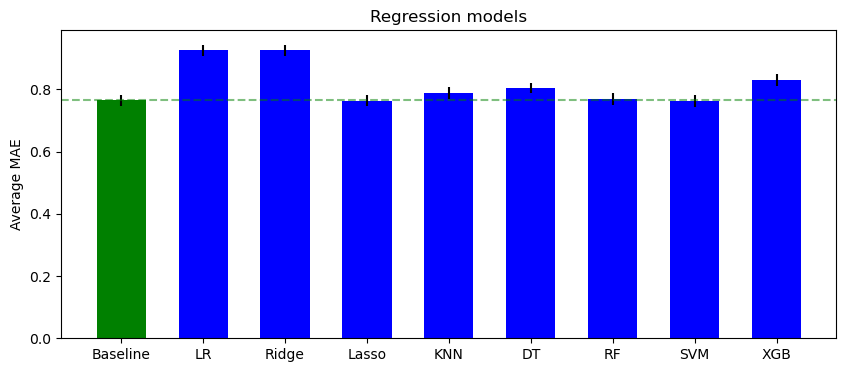

In [74]:
# Retrieve the average MAE and the standard error of the MAE. 
mae = [df_summary_lr['mae_baseline'].mean(), 
       df_summary_lr['mae_model'].mean(), 
       df_summary_ridge['mae_model'].mean(), 
       df_summary_lasso['mae_model'].mean(), 
       df_summary_knn['mae_model'].mean(), 
       df_summary_dt['mae_model'].mean(), 
       df_summary_rf['mae_model'].mean(), 
       df_summary_svm['mae_model'].mean(),
       df_summary_xgb['mae_model'].mean()]
mae_se = [np.std(df_summary_lr['mae_baseline']) / np.sqrt(df_summary_lr['mae_baseline'].shape[0]), 
          np.std(df_summary_lr['mae_model']) / np.sqrt(df_summary_lr['mae_model'].shape[0]), 
          np.std(df_summary_ridge['mae_model']) / np.sqrt(df_summary_ridge['mae_model'].shape[0]), 
          np.std(df_summary_lasso['mae_model']) / np.sqrt(df_summary_lasso['mae_model'].shape[0]), 
          np.std(df_summary_knn['mae_model']) / np.sqrt(df_summary_knn['mae_model'].shape[0]), 
          np.std(df_summary_dt['mae_model']) / np.sqrt(df_summary_dt['mae_model'].shape[0]), 
          np.std(df_summary_rf['mae_model']) / np.sqrt(df_summary_rf['mae_model'].shape[0]), 
          np.std(df_summary_svm['mae_model']) / np.sqrt(df_summary_svm['mae_model'].shape[0]),
          np.std(df_summary_xgb['mae_model']) / np.sqrt(df_summary_xgb['mae_model'].shape[0])]

# Display the average MAE and its standard error in a bar plot. 
fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize = (10, 4))
axes.bar(range(9), mae, width = 0.6, color = ['green', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'blue'])
axes.errorbar(range(9), mae, yerr = mae_se, fmt = 'None', color = 'black')
axes.axhline(mae[0], 0, 1, color = 'green', linestyle = 'dashed', alpha = 0.5)
axes.set_xticks(range(9), labels = ['Baseline', 'LR', 'Ridge', 'Lasso', 'KNN', 'DT', 'RF', 'SVM', 'XGB'])
axes.set_ylabel('Average MAE')
axes.set_title('Regression models');

In [75]:
# If the cross-validation results path does not exist, create it. 
if not os.path.exists(results_path + 'regression/cross_validation/'):
    os.makedirs(results_path + 'regression/cross_validation/')
if not os.path.exists(results_path + 'regression/cross_validation/cv_iteration_' + str(cv_iteration) + '/'):
    os.makedirs(results_path + 'regression/cross_validation/cv_iteration_' + str(cv_iteration) + '/')

# Define the regression cross-validation results path. 
regression_cv_results_path = results_path + 'regression/cross_validation/cv_iteration_' + str(cv_iteration) + '/'

In [76]:
# Save the models into Pickle files. 
with open(regression_cv_results_path + 'dict_models_lr.p', 'wb') as file:
    pickle.dump(dict_models_lr, file)
with open(regression_cv_results_path + 'dict_models_ridge.p', 'wb') as file:
    pickle.dump(dict_models_ridge, file)
with open(regression_cv_results_path + 'dict_models_lasso.p', 'wb') as file:
    pickle.dump(dict_models_lasso, file)
with open(regression_cv_results_path + 'dict_models_knn.p', 'wb') as file:
    pickle.dump(dict_models_knn, file)
with open(regression_cv_results_path + 'dict_models_dt.p', 'wb') as file:
    pickle.dump(dict_models_dt, file)
with open(regression_cv_results_path + 'dict_models_rf.p', 'wb') as file:
    pickle.dump(dict_models_rf, file)
with open(regression_cv_results_path + 'dict_models_svm.p', 'wb') as file:
    pickle.dump(dict_models_svm, file)
with open(regression_cv_results_path + 'dict_models_xgb.p', 'wb') as file:
    pickle.dump(dict_models_xgb, file)

# Save the predictions into Pickle files. 
with open(regression_cv_results_path + 'dict_predictions_lr.p', 'wb') as file:
    pickle.dump(dict_predictions_lr, file)
with open(regression_cv_results_path + 'dict_predictions_ridge.p', 'wb') as file:
    pickle.dump(dict_predictions_ridge, file)
with open(regression_cv_results_path + 'dict_predictions_lasso.p', 'wb') as file:
    pickle.dump(dict_predictions_lasso, file)
with open(regression_cv_results_path + 'dict_predictions_knn.p', 'wb') as file:
    pickle.dump(dict_predictions_knn, file)
with open(regression_cv_results_path + 'dict_predictions_dt.p', 'wb') as file:
    pickle.dump(dict_predictions_dt, file)
with open(regression_cv_results_path + 'dict_predictions_rf.p', 'wb') as file:
    pickle.dump(dict_predictions_rf, file)
with open(regression_cv_results_path + 'dict_predictions_svm.p', 'wb') as file:
    pickle.dump(dict_predictions_svm, file)
with open(regression_cv_results_path + 'dict_predictions_xgb.p', 'wb') as file:
    pickle.dump(dict_predictions_xgb, file)